# Definitions

## Manual Definition

In [ ]:
from types import SimpleNamespace
overwrite = SimpleNamespace()

# overwrite.model_space = "VAE"
overwrite.model_space = "PX"

overwrite.scale_factor = 1 # PRoPE / LVSM pre-training
# overwrite.scale_factor = 2 # LVSM fine-tuning

overwrite.patch_size = 8 # LVSM / PRoPE
overwrite.patch_size = 1 # option b for VAE
overwrite.patch_size = 32 # option b for PX

# overwrite.supervise_views = 4 # → will result in 4 in, 1 out
overwrite.supervise_views = 0 # → will result in 1 in, 1 out

# overwrite.dim_feedforward = 3072 # LVSM / PRoPE - large
overwrite.dim_feedforward = 1024 # PRoPE - small

overwrite.num_layers = 6 # PRoPE - small
# overwrite.num_layers = 12 # PRoPE - large

# LVSM:
# For scene-level experiments We use 2 input views and 6 target views for each training example.

## Generating all Combinations

In [ ]:
from itertools import product
from types import SimpleNamespace

def generate_overwrite_configs():
    model_spaces = ["VAE", "PX"]
    scale_factors = [1, 2]
    # scale_factors = [1]
    # supervise_views = [0, 3, 7, 15] # dataloader will load n = (supervise_views + 2 images) and use n-1 for training => supervise_views + 1 tanslates to context images
    supervise_views = [1] # dataloader will load n = (supervise_views + 2 images) and use n-1 for training => supervise_views + 1 tanslates to context images
    dim_feedforwards = [1024, 3072]
    num_layers = [6, 12]

    all_configs = []

    for model_space in model_spaces:

        # patch_size depends on model_space
        if model_space == "VAE":
            # patch_sizes = [1, 8]
            patch_sizes = [2]
        else:  # PX
            # patch_sizes = [8, 64]
            patch_sizes = [8]

        # make cartesian product with allowed settings
        for (scale_factor,
             patch_size,
             sv,
             dff,
             nl) in product(scale_factors,
                            patch_sizes,
                            supervise_views,
                            dim_feedforwards,
                            num_layers):

            ow = SimpleNamespace()
            ow.model_space = model_space
            ow.scale_factor = scale_factor
            ow.patch_size = patch_size
            ow.supervise_views = sv
            ow.dim_feedforward = dff
            ow.num_layers = nl

            all_configs.append(ow)

    return all_configs

# Example usage:
configs = generate_overwrite_configs()
print("Total configs:", len(configs))
print(vars(configs[11]))

Total configs: 64
{'model_space': 'VAE', 'scale_factor': 1, 'patch_size': 2, 'supervise_views': 7, 'dim_feedforward': 3072, 'num_layers': 12}


# Functions

In [61]:
import sys
import os
project_root = os.path.abspath("..")
sys.path.append(project_root)

import torch
import yaml
import re
import glob
from pathlib import Path

from src.models.lvsm_decoder_only import LVSMDecoderOnlyModel
from src.configs.lvsm_decoder_only_config import (
    LVSMDecoderOnlyModelConfig,
    RayEncodingType,
    PosEncType,
)
from src.prope.utils.transformer import (
    TransformerEncoderConfig,
    TransformerEncoderLayerConfig,
)


from src.data.dataset import TrainDataset
from src.data.latent_dataset import TrainLatentDataset
from main import LVSMLauncher, LVSMLauncherConfig

device = "cuda" if torch.cuda.is_available() else "cpu"


def get_config(overwrite):           
    
    dir = "../assets/vae_config.yaml" if overwrite.model_space == "VAE" else "../assets/px_config.yaml"
    raw = Path(dir).read_text()    
    clean = re.sub(r"!!python/[^ \n]+", "", raw)   # strip python tags

    config_dict = yaml.safe_load(clean)    
    cfg = LVSMLauncherConfig()

    for k, v in config_dict.items():
        if k != "model_config":   # we'll rebuild this separately
            setattr(cfg, k, v)
    
    m = config_dict["model_config"]

    # Enums were dumped as single-item lists
    ray_encoding = RayEncodingType(m["ray_encoding"][0])
    pos_enc      = PosEncType(m["pos_enc"][0])
    
    layer_cfg = m["encoder"]["layer"]

    encoder_layer = TransformerEncoderLayerConfig(
        d_model=layer_cfg["d_model"],
        nhead=layer_cfg["nhead"],
        dim_feedforward=overwrite.dim_feedforward,
        dropout=layer_cfg["dropout"],
        activation=torch.nn.functional.relu,  # original activation
        batch_first=layer_cfg["batch_first"],
        bias=layer_cfg["bias"],
        layer_norm_eps=layer_cfg["layer_norm_eps"],
        modulation_activation=layer_cfg["modulation_activation"],
        norm_first=layer_cfg["norm_first"],
        norm_type=layer_cfg["norm_type"],
        elementwise_affine=layer_cfg["elementwise_affine"],
        qk_norm=layer_cfg["qk_norm"],
    )
    
    encoder = TransformerEncoderConfig(
        layer=encoder_layer,
        num_layers=overwrite.num_layers,
        input_norm=m["encoder"]["input_norm"],
        output_norm=m["encoder"]["output_norm"],
        checkpointing=m["encoder"]["checkpointing"],
    )

    # Full model config
    model_cfg = LVSMDecoderOnlyModelConfig(
        ref_views=m["ref_views"],
        tar_views=m["tar_views"],
        encoder=encoder,
        img_shape=tuple([m["img_shape"][0]*overwrite.scale_factor, m["img_shape"][1]*overwrite.scale_factor,m["img_shape"][2]]),
        cam_shape=tuple([m["cam_shape"][0]*overwrite.scale_factor, m["cam_shape"][1]*overwrite.scale_factor,m["cam_shape"][2]]),        
        patch_size=overwrite.patch_size,        
        ray_encoding=ray_encoding,
        pos_enc=pos_enc,
    )
    
    cfg.model_config = model_cfg    
    return cfg

def load_checkpoint(model, dir):
    def get_latest_checkpoint(ckpt_dir):
        ckpts = sorted(glob.glob(os.path.join(ckpt_dir, "*.pt")))
        return ckpts[-1] if ckpts else None

    ckpt_path = get_latest_checkpoint(f"{dir}/ckpts")
    print("Loading checkpoint:", ckpt_path)

    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    state_dict = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model"].items()}
    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)
    return model



def load_single_batch(cfg: LVSMLauncherConfig, overwrite):
    """
    Loads ONE batch from the appropriate dataset based on cfg.model_space.
    Returns ref_imgs, tar_imgs, ref_cams, tar_cams, ref_paths, tar_paths.
    """

    launcher = LVSMLauncher(cfg)
    
    if cfg.model_space == "PX":
        # scenes = sorted(glob.glob("../data/data_processed/realestate10k/train/*"))
        # scenes = sorted(glob.glob("../data/data_processed/realestate10k/overfit/*"))
        scenes = sorted(glob.glob("../data/data_processed/realestate10k/overfit-2/*"))
        dataset = TrainDataset(
            scenes,
            patch_size=cfg.dataset_patch_size,
            zoom_factor=cfg.train_zoom_factor,
            random_zoom=cfg.random_zoom,            
            supervise_views=overwrite.supervise_views, # will return 2 + supervise_views images
            upscale_factor=overwrite.scale_factor
        )
    else:
        # scenes = sorted(glob.glob("../data/data_processed/realestate10k_latent/train/*"))
        # scenes = sorted(glob.glob("../data/data_processed/realestate10k_latent/overfit/*"))
        scenes = sorted(glob.glob("../data/data_processed/realestate10k_latent/overfit-2/*"))        
        dataset = TrainLatentDataset(
            scenes,                
            supervise_views=overwrite.supervise_views,       
            upscale_factor=overwrite.scale_factor
        )    

    data = dataset[0] # just one scene
    data["image"] = data["image"].unsqueeze(0)
    data["K"] = data["K"].unsqueeze(0)
    data["camtoworld"] = data["camtoworld"].unsqueeze(0)
    data["image_path"] = [data["image_path"]]  # wrap in list    

    input_views = data["K"].shape[1] - cfg.dataset_supervise_views # input views = available images - 1 (output)
    
    processed = launcher.preprocess(data, input_views=input_views)

    ref_imgs = processed["ref_imgs"]
    tar_imgs = processed["tar_imgs"]
    ref_cams = processed["ref_cams"]
    tar_cams = processed["tar_cams"]
    ref_paths = processed["ref_paths"]
    tar_paths = processed["tar_paths"]

    return ref_imgs, tar_imgs, ref_cams, tar_cams, ref_paths, tar_paths



import time
import torch
import torch.nn.functional as F

def tensor_bytes(x: torch.Tensor) -> int:
    return x.numel() * x.element_size()

def encode_tensors(img: torch.Tensor, vae, device, sequentially = True) -> torch.Tensor:
    """
    Accepts:
        [H, W, 3]
        [V, H, W, 3]
        [B, V, H, W, 3]

    Returns:
        Same leading dims, but encoded latents:
        [.., H_down, W_down, C_latent]
    """

    # img = img.to(device).float()

    # Original leading dims: (), (V), or (B, V)
    orig_shape = img.shape[:-3]
    H, W, C = img.shape[-3:]
    assert C == 3, f"Expected RGB input but got {C} channels"

    # Flatten leading dims
    img = img.reshape(-1, H, W, C)        # [N, H, W, 3]

    # Convert to NCHW
    img = img.permute(0, 3, 1, 2)         # [N, 3, H, W]

    # Scale to [-1, 1] just like training
    img = img * 2 - 1

    with torch.no_grad():
        if sequentially:
            latents_cpu = []
            for i in range(img.shape[0]):
                posterior = vae.encode(img[i].unsqueeze(0).to(device).float())
                latent = posterior.latent_dist.mean.squeeze(0).detach().cpu()  # offload
                latents_cpu.append(latent)

            latents = torch.stack(latents_cpu, dim=0).to(img.device)  # back to GPU
        else:
            posterior = vae.encode(img)
            latents = posterior.latent_dist.mean   # [N, C_lat, H_down, W_down]

    # Back to NHWC
    latents = latents.permute(0, 2, 3, 1)   # [N, H_down, W_down, C_lat]


    # Restore original leading dims
    latents = latents.reshape(*orig_shape,
                              latents.shape[1],
                              latents.shape[2],
                              latents.shape[3])

    return latents


def scale_spatial(img: torch.Tensor, factor: int) -> torch.Tensor:
    """
    Inputs:
        img: [B, V, H, W, C]
    Returns:
        [B, V, H*factor, W*factor, C]

    Uses bilinear interpolation. Assumes img is on any device.
    """

    B, V, H, W, C = img.shape
    img_nchw = img.permute(0, 1, 4, 2, 3).reshape(B*V, C, H, W)

    img_up = F.interpolate(
        img_nchw,
        size=(H * factor, W * factor),
        mode="bilinear",
        align_corners=False
    )
    img_up = img_up.reshape(B, V, C, H*factor, W*factor).permute(0, 1, 3, 4, 2)

    return img_up


def run_inference_with_metrics(model, launcher, ref_imgs, ref_cams, tar_cams, cfg, device="cuda", scale_factor=1):    

    model_params = sum(p.numel() for p in model.parameters())
    
    input_tensors = [ref_imgs]
    input_bytes = sum(tensor_bytes(t) for t in input_tensors if isinstance(t, torch.Tensor))    
    
    forward_memory_mb = 0.0
    encode_memory_mb = 0.0
    decode_memory_mb = 0.0
    peak_memory_mb = 0.0
    encode_peak = 0.0
    encode_time_ms = 0.0

    t_enc1 = time.time()
    

    if cfg.model_space == "VAE":
        decoded = launcher.decode_tensors(ref_imgs).cpu()
        # print(f"ref_imgs.shape {ref_imgs.shape}")             
        if scale_factor > 1:
            decoded = scale_spatial(decoded, scale_factor)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats(device)
        
        t_enc1 = time.time()
        encode_tensors(decoded, launcher.vae32, device, sequentially=True)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        encode_time_ms = (time.time() - t_enc1)* 1000
        if torch.cuda.is_available():
            encode_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2)
        encode_peak = torch.cuda.max_memory_allocated(device)

    # ------------------------------------------
    # Forward pass timing + memory
    # ------------------------------------------
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize()
    t_fwd0 = time.time()

    # print(f"ref_imgs.shape {ref_imgs.shape}")
    # print(f"ref_cams.shape {len(ref_cams)}")
    # print(f"tar_cams.shape {len(tar_cams)}")
    with torch.inference_mode():
        out = model(ref_imgs.to(device), ref_cams, tar_cams)

    torch.cuda.synchronize()
    t_fwd1 = time.time()

    forward_time_ms = (t_fwd1 - t_fwd0) * 1000

    # Memory AFTER forward pass
    if torch.cuda.is_available():
        forward_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2)

    # Keep the forward peak BEFORE decoding wipes it out
    forward_peak = torch.cuda.max_memory_allocated(device)
    
    if cfg.model_space == "VAE":

        # Reset for decode-only measurement
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize()
        t_dec0 = time.time()

        decoded = launcher.decode_tensors(out[0])

        torch.cuda.synchronize()
        t_dec1 = time.time()
        decode_time_ms = (t_dec1 - t_dec0) * 1000

        decode_memory_mb = torch.cuda.max_memory_allocated(device) / (1024**2)

    else:
        decoded = torch.sigmoid(out)
        decode_time_ms = 0.0
        decode_memory_mb = 0.0
    
    peak_memory_mb = max(encode_peak, forward_peak, torch.cuda.max_memory_allocated(device)) / (1024**2)    
    total_time_ms = forward_time_ms + decode_time_ms + encode_time_ms


    return {
        "model_space": cfg.model_space,
        "patch_size" : cfg.model_config.patch_size,
        "layers": cfg.model_config.encoder.num_layers,
        "dim_feedforward": cfg.model_config.encoder.layer.dim_feedforward,
        "scale_factor" : scale_factor,        
        "ref_views" : ref_imgs.shape[1],
        "model_params": model_params,
        "input_bytes": input_bytes,
        "input_MB": input_bytes / (1024**2),
        "encode_time_ms": encode_time_ms,
        "forward_time_ms": forward_time_ms,
        "decode_time_ms": decode_time_ms,
        "total_time_ms": total_time_ms,
        "encode_memory_mb": encode_memory_mb,
        "forward_memory_mb": forward_memory_mb,
        "decode_memory_mb": decode_memory_mb,
        "peak_memory_mb": peak_memory_mb,
        # "output_shape": tuple(out.shape),
        # "decoded_shape": tuple(decoded.shape),
    }


In [5]:

def evaluate(config):
    cfg = get_config(config)
    model = LVSMDecoderOnlyModel(cfg.model_config).to(device)
    model.eval()

    ref_imgs, tar_imgs, ref_cams, tar_cams, ref_paths, tar_paths = load_single_batch(cfg, config)

    launcher = LVSMLauncher(cfg)
    return run_inference_with_metrics(
        model=model,
        launcher=launcher,
        ref_imgs=ref_imgs,
        ref_cams=ref_cams,
        tar_cams=tar_cams,
        cfg=cfg,
        scale_factor=config.scale_factor
    )

In [9]:
results_file = "../results/performance_comparison/260129_results_6.json"

In [56]:
configs

[namespace(model_space='VAE',
           scale_factor=1,
           patch_size=2,
           supervise_views=7,
           dim_feedforward=3072,
           num_layers=12)]

In [ ]:
results = []

import json

n_iterations = 10
total = len(configs) * n_iterations
count = 0

for config in configs:
    for n in range(n_iterations):
        metrics = evaluate(config)        
        results.append(metrics)      
        count += 1
        print(f"[{count}/{total}] {count/total*100:.1f}% done")  


with open(results_file, "w") as f:
    json.dump(results,f,indent=4)


NameError: name 'configs' is not defined

# Plots

In [3]:
import json
from pathlib import Path
from collections import defaultdict

# Load results
path = Path(results_file)
data = json.loads(path.read_text())

print("\n=== Loaded entries:", len(data), "===\n")

# Print the distinct values for each field
fields = ["model_space", "patch_size", "scale_factor", "ref_views",
          "layers", "dim_feedforward"]

distinct = {f: set() for f in fields}

for e in data:
    for f in fields:
        distinct[f].add(e.get(f))

print("=== Distinct values in the dataset ===")
for f in distinct:
    print(f"{f}: {sorted(distinct[f])}")



=== Loaded entries: 640 ===

=== Distinct values in the dataset ===
model_space: ['PX', 'VAE']
patch_size: [2, 8]
scale_factor: [1, 2]
ref_views: [1, 4, 8, 16]
layers: [6, 12]
dim_feedforward: [1024, 3072]


Total unique configs: 64


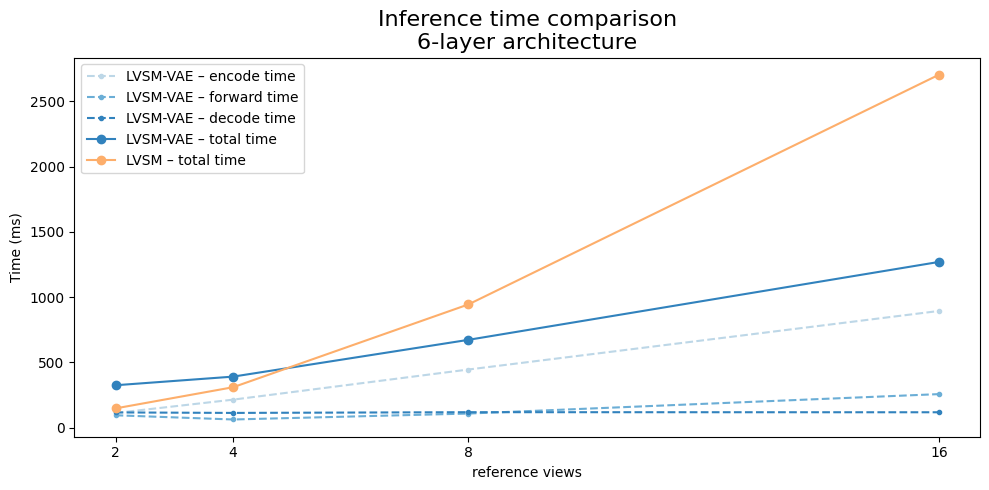

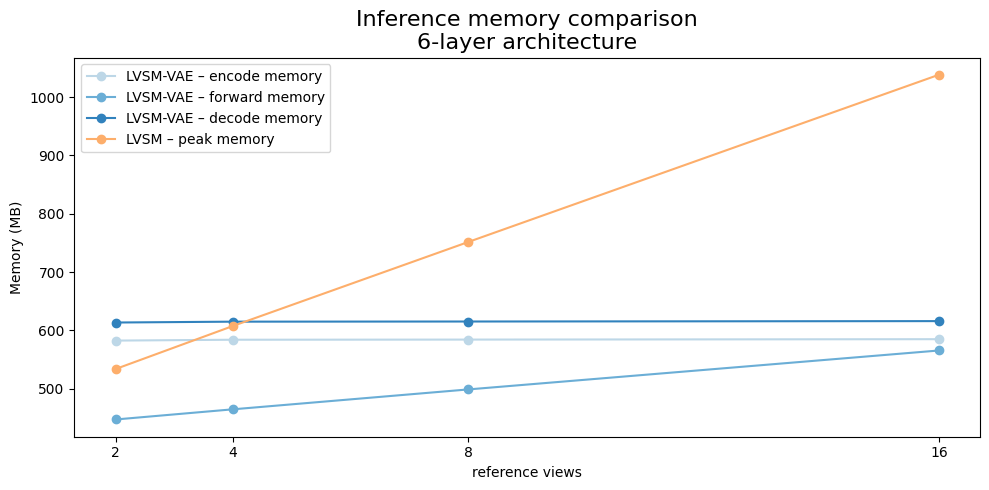

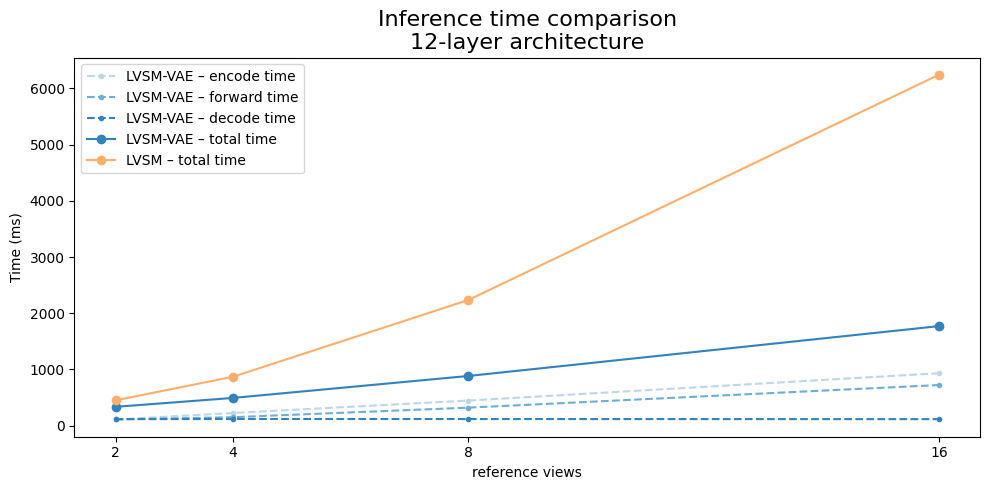

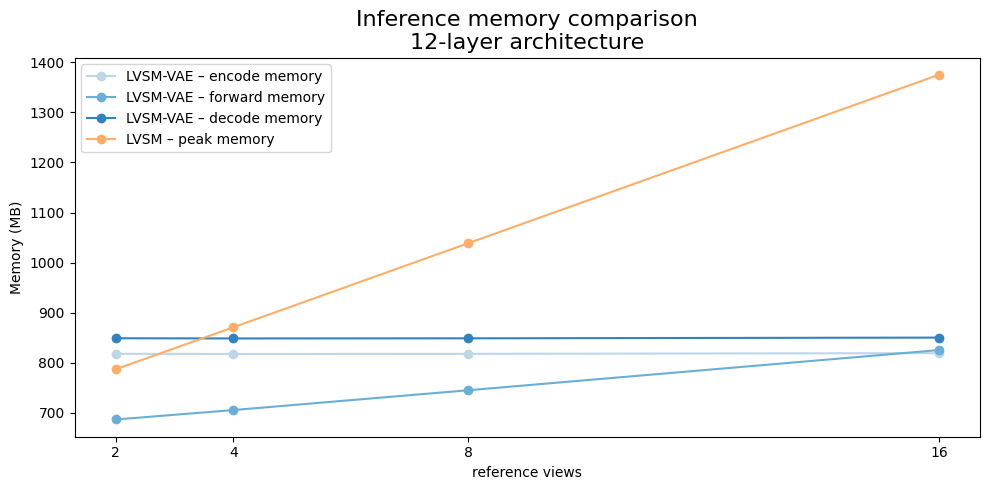

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict


path = Path(results_file)
data = json.loads(path.read_text())


def extract_ref_views(labels):
    # labels look like "sf=1, rv=4"
    return [int(lbl.split("rv=")[1]) for lbl in labels]


# --- group and average ---
groups = defaultdict(list)
for e in data:
    key = (
        e["model_space"],
        e["patch_size"],
        e["scale_factor"],
        e["ref_views"],
        e["layers"],
        e["dim_feedforward"],
    )
    groups[key].append(e)

mean_results = {}
for key, items in groups.items():
    avg = {}
    for k, v in items[0].items():
        if isinstance(v, (int, float)):
            avg[k] = sum(x.get(k, 0) for x in items) / len(items)
        else:
            avg[k] = v
    mean_results[key] = avg

print("Total unique configs:", len(mean_results))


def get_unique(field, *, filters=None):
    """Return sorted unique values for a field across mean_results keys."""
    filters = filters or {}
    vals = set()
    for (ms, ps, sf, rv, lyr, ff) in mean_results.keys():
        if "model_space" in filters and ms not in filters["model_space"]:
            continue
        if "patch_size" in filters and ps not in filters["patch_size"]:
            continue
        if "scale_factor" in filters and sf not in filters["scale_factor"]:
            continue
        if "ref_views" in filters and rv not in filters["ref_views"]:
            continue
        if "layers" in filters and lyr not in filters["layers"]:
            continue
        if "dim_feedforward" in filters and ff not in filters["dim_feedforward"]:
            continue

        mapping = {
            "model_space": ms,
            "patch_size": ps,
            "scale_factor": sf,
            "ref_views": rv,
            "layers": lyr,
            "dim_feedforward": ff,
        }
        vals.add(mapping[field])
    return sorted(vals)


def available_conditions(vae_patch, px_patch, layers, dff, scale_factors=None, ref_views=None):
    """Discover (sf, rv) pairs that exist for BOTH VAE and PX for the given patches + hyperparams."""
    conds = set()
    for (ms, ps, sf, rv, lyr, ff) in mean_results.keys():
        if lyr != layers or ff != dff:
            continue
        if scale_factors is not None and sf not in scale_factors:
            continue
        if ref_views is not None and rv not in ref_views:
            continue        
        conds.add((sf, rv))

    final = []
    for sf, rv in sorted(conds, key=lambda x: (x[1], x[0])):
        k_vae = ("VAE", vae_patch, sf, rv, layers, dff)
        k_px  = ("PX",  px_patch,  sf, rv, layers, dff)
        if k_vae in mean_results and k_px in mean_results:
            final.append((sf, rv))
        else:            
            pass

    return final


def collect_subset(vae_patch, px_patch, layers, dff, scale_factors=None, ref_views=None, conditions=None):
    if conditions is None:
        conditions = available_conditions(
            vae_patch, px_patch, layers, dff,
            scale_factors=scale_factors,
            ref_views=ref_views
        )

    labels = [f"sf={sf}, rv={rv}" for sf, rv in conditions]

    subset = []
    for sf, rv in conditions:
        key_vae = ("VAE", vae_patch, sf, rv, layers, dff)
        key_px  = ("PX",  px_patch,  sf, rv, layers, dff)
        subset.append((mean_results.get(key_vae), mean_results.get(key_px)))

    return labels, subset


def safe_get(d, k, default=0.0):
    return float(d.get(k, default)) if d is not None else float(default)


# color scheme: blues for VAE, orange for PX
colors = {
    "vae_encode":  "#bdd7e7",
    "vae_forward": "#6baed6",
    "vae_decode":  "#3182bd",
    "px_total":    "#fdae6b",
}


def plot_subset(labels, subset, title_prefix, layers, ff_dim, mode="bar"):
    if not labels:
        print(f"No comparable conditions found for {title_prefix} (layers={layers}, dff={ff_dim}).")
        return

    y = np.arange(len(labels))
    ref_views = extract_ref_views(labels)

    # --- collect metrics ---
    vae_enc  = np.array([safe_get(v, "encode_time_ms")  for v, _ in subset])
    vae_fwd  = np.array([safe_get(v, "forward_time_ms") for v, _ in subset])
    vae_dec  = np.array([safe_get(v, "decode_time_ms")  for v, _ in subset])
    vae_total = vae_enc + vae_fwd + vae_dec

    px_total = np.array([safe_get(p, "total_time_ms") for _, p in subset])

    vae_mem = (
        np.array([safe_get(v, "encode_memory_mb")  for v, _ in subset]) +
        np.array([safe_get(v, "forward_memory_mb") for v, _ in subset]) +
        np.array([safe_get(v, "decode_memory_mb")  for v, _ in subset])
    )
    px_mem = np.array([safe_get(p, "peak_memory_mb") for _, p in subset])

    # ======================
    # BAR MODE
    # ======================
    if mode == "bar":
        fig, ax = plt.subplots(figsize=(12, 6))
        h = 0.35

        ax.barh(y - h/2, vae_enc, h, color=colors["vae_encode"],  label="VAE – encode")
        ax.barh(y - h/2, vae_fwd, h, left=vae_enc,
                color=colors["vae_forward"], label="VAE – forward")
        ax.barh(y - h/2, vae_dec, h,
                left=vae_enc + vae_fwd,
                color=colors["vae_decode"], label="VAE – decode")
        ax.barh(y + h/2, px_total, h,
                color=colors["px_total"], label="PX – total time")

        ax.set_yticks(y)
        ax.set_yticklabels(labels)
        ax.set_xlabel("Time (ms)")
        ax.set_title(f"Inference Time comparison\n{layers}-layer architecture", fontsize=16)
        # ax.set_title(f"Inference Time comparison\n{layers}-layer architecture - 512x512 images", fontsize=16)
        ax.legend()
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(12, 6))
        h2 = 0.2

        ax.barh(y - 1.5*h2, vae_enc, h2, color=colors["vae_encode"],  label="LVSM-VAE – encode memory")
        ax.barh(y - 0.5*h2, vae_fwd, h2, color=colors["vae_forward"], label="LVSM-VAE – forward memory")
        ax.barh(y + 0.5*h2, vae_dec, h2, color=colors["vae_decode"],  label="LVSM-VAE – decode memory")
        ax.barh(y + 1.5*h2, px_mem,  h2, color=colors["px_total"],    label="LVSM – peak memory")

        ax.set_yticks(y)
        ax.set_yticklabels(labels)
        ax.set_xlabel("Memory (MB)")
        ax.set_title(f"Inference memory comparison\n{layers}-layer architecture", fontsize=16)
        # ax.set_title(f"Inference memory comparison\n{layers}-layer architecture - 512x512 images", fontsize=16)
        ax.legend()
        plt.tight_layout()
        plt.show()

    # ======================
    # LINE MODE
    # ======================
    elif mode == "line":
    # -------- TIME --------
        fig, ax = plt.subplots(figsize=(10, 5))

        ax.plot(ref_views, vae_enc,
                marker=".", linestyle="--", color=colors["vae_encode"], label="LVSM-VAE – encode time")
        ax.plot(ref_views, vae_fwd,
                marker=".", linestyle="--", color=colors["vae_forward"], label="LVSM-VAE – forward time")
        ax.plot(ref_views, vae_dec,
                marker=".", linestyle="--", color=colors["vae_decode"], label="LVSM-VAE – decode time")
        ax.plot(ref_views, vae_total,
                marker="o", color=colors["vae_decode"], label="LVSM-VAE – total time")
        ax.plot(ref_views, px_total,
                marker="o", color=colors["px_total"], label="LVSM – total time")

        ax.set_xlabel("reference views")
        ax.set_ylabel("Time (ms)")
        ax.set_xticks(ref_views)
        ax.set_title(f"Inference time comparison\n{layers}-layer architecture", fontsize=16)
        # ax.set_title(f"Inference time comparison\n{layers}-layer architecture - 512x512 images", fontsize=16)
        ax.legend()
        plt.tight_layout()
        plt.show()

        # -------- MEMORY (individual contributions) --------
        fig, ax = plt.subplots(figsize=(10, 5))

        vae_enc_mem = np.array([safe_get(v, "encode_memory_mb")  for v, _ in subset])
        vae_fwd_mem = np.array([safe_get(v, "forward_memory_mb") for v, _ in subset])
        vae_dec_mem = np.array([safe_get(v, "decode_memory_mb")  for v, _ in subset])
        px_mem      = np.array([safe_get(p, "peak_memory_mb")    for _, p in subset])

        ax.plot(ref_views, vae_enc_mem,
                marker="o", color=colors["vae_encode"], label="LVSM-VAE – encode memory")
        ax.plot(ref_views, vae_fwd_mem,
                marker="o", color=colors["vae_forward"], label="LVSM-VAE – forward memory")
        ax.plot(ref_views, vae_dec_mem,
                marker="o", color=colors["vae_decode"], label="LVSM-VAE – decode memory")
        ax.plot(ref_views, px_mem,
                marker="o", color=colors["px_total"], label="LVSM – peak memory")

        ax.set_xlabel("reference views")
        ax.set_ylabel("Memory (MB)")
        ax.set_xticks(ref_views)
        ax.set_title(f"Inference memory comparison\n{layers}-layer architecture", fontsize=16)
        # ax.set_title(f"Inference memory comparison\n{layers}-layer architecture - 512x512 images", fontsize=16)
        ax.legend()
        plt.tight_layout()
        plt.show()


    else:
        raise ValueError(f"Unknown mode: {mode}")




vae_patch = 2
px_patch  = 8

scale_factors = {1}        
ref_views = None           

layers = 6
dff = 1024

labels, subset = collect_subset(vae_patch, px_patch, layers, dff,
                                scale_factors=scale_factors, ref_views=ref_views)

plot_subset(labels, subset, f"VAE(p{vae_patch}) vs PX(p{px_patch})", layers, dff, mode="line")

layers = 12
dff = 3072

labels, subset = collect_subset(vae_patch, px_patch, layers, dff,
                                scale_factors=scale_factors, ref_views=ref_views)
plot_subset(labels, subset, f"LVSM-VAE vs LVSM", layers, dff, mode="line")
